# Test: A* pathfinding and LLM readout of chosen path

In [68]:
import math
import heapq
import re
from typing import Dict, List, Tuple, Optional

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

## Building map as a graph
# Nodes_List have (x, y) coordinates
# Edges have costs (Manhattan distance), instruction template (for directions to be provided to the human)

class Node:
    def __init__(self, node_id: str, name: str, x: float, y: float):
        self.id = node_id
        self.name = name
        self.x = x
        self.y = y

# List of Nodes_List: 
Node_List: Dict[str, Node] = {
    "entrance": Node("entrance", "Entrance", 0, 0),
    "lobby": Node("lobby", "Lobby", 0, 4),
    "reception": Node("reception", "Reception", 1, 4),
    "cafe": Node("cafe", "Cafe", -3, 4),
    "fountain": Node("fountain", "Water Fountain", -1, 6),
    #"doors": Node("doors", "Past the Doors", 0, 8),
    "doors": Node("doors", "Past the Doors", 0, 9),
    "toilet_m": Node("toilet_m", "Men's Toilets", -3, 8),
    "toilet_f": Node("toilet_f", "Women's Toilets", 3, 8),
    "meeting_room": Node("meeting_room", "Meeting Room 0.01", 6, 8),
    "lecture_room_1": Node("lecture_room_1", "Lecture Room 0.02", 7, 9),
    "supply_closet_1": Node("supply_closet_1", "Supply Closet 1", 7, 11),
    "lecture_room_2": Node("lecture_room_2", "Lecture Room 0.03", 7, 13),
    "lecture_room_3": Node("lecture_room_3", "Large Lecture Hall 0.04", 7, 15),
    "canteen": Node("canteen", "Staff Canteen 0.05", 7, 21),
    "lab": Node("lab", "Student Lab 0.06", 6, 22),
    "lecture_room_4": Node("lecture_room_4", "Lecture Room 0.07", 2, 22),
    "computer_room": Node("computer_room", "Computer Room 0.08", -2, 22),
    "smithee": Node("smithee", "Alan Smithee 0.09", -4, 22),
    "sand": Node("sand", "George Sand 0.10", -6, 22),
    "bird": Node("bird", "Cordwainer Bird 0.11", -7, 21),
    "merchant": Node("merchant", "Paul Merchant 0.12", -7, 19),
    "lecture_room_5": Node("lecture_room_5", "Lecture Room 0.13", -7, 17),
    "supply_closet_2": Node("supply_closet_2", "Supply Closet 2", -7, 15),
    "plinge": Node("plinge", "Walter Plinge 0.14", -7, 13),
    "agnew": Node("agnew", "David Agnew 0.15", -7, 11),
    "jaynes": Node("jaynes", "Roderick Jaynes 0.16", -6, 8),

    # Nodes on each corner of the corridor used to save on unnecessary instruction read-outs to the TTS engine
    "sw_corridor": Node("sw_corridor", "South-West Corridor Corner", -6, 9),
    "nw_corridor": Node("nw_corridor", "North-West Corridor Corner", -6, 21),
    "ne_corridor": Node("ne_corridor", "North-East Corridor Corner", 6, 21),
    "se_corridor": Node("se_corridor", "South-East Corridor Corner", 6, 9),
}
# Edges: (from, to, cost, instruction)
# Costs are Manhattan distance between nodes
Edge_List = [
    # Lobby node at (0, 4); serves as a central reference node for other Nodes_List in the lobby area
    ("entrance", "lobby", 4, "From the entrance, walk forward into the lobby."),
    ("lobby", "entrance", 4, "With the reception on your left, the exit will be in front of you."),
    
    ("lobby", "reception", 1, "The reception will be on the right."),
    ("lobby", "cafe", 3, "The cafe will be on the left."),
    ("lobby", "fountain", 3, "The water fountain will be on the left corner ahead."),
    ("lobby", "doors", 4, "Go through the doors to your front."),

    # Keeping these here in case the reverse instruction doesn't work
    #("reception", "lobby", 1, "Turn back towards the lobby and face your right."),
    #("cafe", "lobby", 3, "Turn back towards the lobby and face your left."),
    #("fountain", "lobby", 3, "Go back towards the lobby."),
    #("doors", "lobby", 4, "Go back through the doors into the lobby."),

    # Through the doors into the office/lecture room area
    # Clockwise edges covered first
    ("doors", "toilet_m", 4, "Turn to the left. The men's toilets will be on your left down the corridor."),
    ("doors", "jaynes", 7, "Turn to the left. Doctor Jaynes' office is at the end of the corridor on the left."),
    ("doors", "sw_corridor", 6, "Go down the corridor and turn to the right."),

    ("sw_corridor", "agnew", 3, "Doctor Agnew's office will be on the left."),
    ("sw_corridor", "plinge", 5, "Down the corridor, Doctor Plinge's office is on the left, past Doctor Agnew's office."),
    ("sw_corridor", "supply_closet_2", 7, "Walk down the corridor. Supply Closet 2 is on the left, past Doctor Plinge's office."),
    ("sw_corridor", "lecture_room_5", 9, "Lecture Room 0.13 is down the corridor on the left, past Supply Closet 2."),
    ("sw_corridor", "merchant", 10, "Professor Merchant's office is down the corridor on the left, past Lecture Room 0.13."),
    ("sw_corridor", "bird", 13, "Doctor Bird's office is at the end of the corridor on the left."),
    ("sw_corridor", "sand", 13, "Doctor Sand's office is at the end of the corridor, straight ahead."),
    ("sw_corridor", "nw_corridor", 12, "Go down the corridor and turn right."),

    ("nw_corridor", "smithee", 3, "Professor Smithee's office is on the left, past Doctor Sand's office."),
    ("nw_corridor", "computer_room", 5, "Computer Room 0.08 is down the corridor on the left, past Professor Smithee's office."),
    ("nw_corridor", "lecture_room_4", 9, "Lecture Room 0.07 is down the corridor on the left, past Computer Room 0.08."),
    ("nw_corridor", "lab", 13, "Student Lab 0.06 is at the end of the corridor on the left."),
    ("nw_corridor", "canteen", 13, "The staff canteen is at the end of the corridor, straight ahead."),
    ("nw_corridor", "ne_corridor", 12, "Go down the corridor and turn right."),

    ("ne_corridor", "lecture_room_3", 7, "Large Lecture Hall 0.04 is down the corridor on the left."),
    ("ne_corridor", "lecture_room_2", 9, "Lecture Room 0.03 is down the corridor on the left, past Large Lecture Hall 0.04."),
    ("ne_corridor", "supply_closet_1", 11, "Supply Closet 1 is down the corridor on the left, past Lecture Room 0.03."),
    ("ne_corridor", "lecture_room_1", 13, "Lecture Room 0.02 is at the end of the corridor on the left."),
    ("ne_corridor", "meeting_room", 13, "The meeting room is at the end of the corridor, straight ahead."),
    ("ne_corridor", "se_corridor", 12, "Go down the corridor and turn right."),

    ("se_corridor", "toilet_f", 4, "The women's toilets are to the left, past the meeting room."),
    ("se_corridor", "doors", 6, "Go down the corridor, towards the doors to the lobby."),
        
    # Anti-clockwise directions covered next
    ("doors", "toilet_f", 4, "Turn to the right. The women's toilets will be on your right down the corridor."),
    ("doors", "meeting_room", 7, "Turn to the right. The meeting room is at the end of the corridor on the right."),
    ("doors", "lecture_room_1", 7, "Turn to the right. Lecture Room 0.02 is at the end of the corridor, straight ahead."),
    ("doors", "se_corridor", 6, "Go down the corridor and turn left."),

    ("se_corridor", "supply_closet_1", 3, "Supply Closet 1 is on the right, past Lecture Room 0.02."),
    ("se_corridor", "lecture_room_2", 5, "Lecture Room 0.03 is down the corridor on the right, past Supply Closet 1."),
    ("se_corridor", "lecture_room_3", 7, "Large Lecture Hall 0.04 is down the corridor on the right, past Lecture Room 0.03."),
    ("se_corridor", "canteen", 13, "The staff canteen is at the end of the corridor on the right."),
    ("se_corridor", "lab", 13, "Student Lab 0.06 is at the end of the corridor, straight ahead."),
    ("se_corridor", "ne_corridor", 12, "Go down the corridor and turn left."),

    ("ne_corridor", "lecture_room_4", 5, "Lecture Room 0.07 is down the corridor on the left."),
    ("ne_corridor", "computer_room", 9, "Computer Room 0.08 is down the corridor on the right, past Lecture Room 0.07."),
    ("ne_corridor", "smithee", 11, "Professor Smithee's office is down the corridor on the right, past Computer Room 0.08."),
    ("ne_corridor", "sand", 13, "Doctor Sand's office is at the end of the corridor on the right."),
    ("ne_corridor", "bird", 13, "Doctor Bird's office is at the end of the corridor, straight ahead."),
    ("ne_corridor", "nw_corridor", 12, "Go down the corridor and turn left."),

    ("nw_corridor", "merchant", 3, "Professor Merchant's office is down the corridor on the right."),
    ("nw_corridor", "lecture_room_5", 5, "Lecture Room 0.13 is down the corridor on the right, past Professor Merchant's office."),
    ("nw_corridor", "supply_closet_2", 7, "Supply Closet 2 is down the corridor on the right, past Lecture Room 0.13."),
    ("nw_corridor", "plinge", 9, "Doctor Plinge's office is down the corridor on the right, past Supply Closet 2."),
    ("nw_corridor", "agnew", 11, "Doctor Agnew's office is down the corridor on the right, past Doctor Plinge's office."),
    ("nw_corridor", "jaynes", 13, "Doctor Jayne's office is at the end of the corridor, straight ahead."),
    ("nw_corridor", "sw_corridor", 12, "Go down the corridor and turn left."),

    ("sw_corridor", "toilet_m", 4, "The men's toilets are on the right, past Doctor Jaynes' office."),
    ("sw_corridor", "doors", 6, "Go down the corridor, towards the doors to the lobby."),
    
]

Graph: Dict[str, List[Tuple[str, float, str]]] = {nid: [] for nid in Node_List}
for a, b, cost, instr in Edge_List:
    Graph[a].append((b, cost, instr))
    Graph[b].append((a, cost, f"Go back toward {Node_List[a].name}.")) # simple reverse instruction

In [69]:
# Retaining node-by-node directions as backup
    #("toilet_m", "jaynes", 3, "Go past them and Doctor Jaynes' office will be on the left."),
    #("jaynes", "agnew", 4, "Turn right and go down the corridor. Doctor Agnew's office will be on the left."),
    #("agnew", "plinge", 2, "Past this, Doctor Plinge's office is beyond this to the left."),
    #("plinge", "supply_closet_2", 2, "Pass the supply closet to the left."),
    #("supply_closet_2", "lecture_room_5", 2, "Past this, Lecture Room 0.13 will be on the left."),
    #("lecture_room_5", "merchant", 2, "Past this, Professor Merchant's office will be on the left."),
    #("merchant", "bird", 2, "Past this, Doctor Bird's office will be on the left."),
    #("bird", "sand", 1, "Past this, Doctor Sand's office will be straight ahead."),
    #("sand", "smithee", 2, "Turn right down the corridor. Professor Smithee's office will be on the left."),
    #("smithee", "computer_room", 2, "Past this, Computer Room 0.08 will be on the left."),
    #("computer_room", "lecture_room_4", 4, "Past this, Lecture Room 0.07 will be on the left."),

In [72]:
# ============================================================
# 2) A* PATHFINDING
# ============================================================

def heuristic(a: str, b: str) -> float:
    """Euclidean distance heuristic using node coordinates."""
    na, nb = Node_List[a], Node_List[b]
    return math.hypot(na.x - nb.x, na.y - nb.y)

def astar(start: str, goal: str) -> Optional[List[str]]:
    """
    Returns a list of edge instructions from start to goal, or None if no path.
    """
    open_heap = []
    heapq.heappush(open_heap, (0 + heuristic(start, goal), 0, start))
    came_from: Dict[str, Optional[str]] = {start: None}
    came_instr: Dict[str, Optional[str]] = {start: None}
    g_score: Dict[str, float] = {start: 0}

    while open_heap:
        f, g, current = heapq.heappop(open_heap)

        if current == goal:
            # reconstruct instruction list
            steps = []
            cur = goal
            while cur != start:
                steps.append(came_instr[cur])
                cur = came_from[cur]
            steps.reverse()
            return steps

        for neighbor, cost, instr in Graph[current]:
            tentative_g = g_score[current] + cost
            if tentative_g < g_score.get(neighbor, float("inf")):
                came_from[neighbor] = current
                came_instr[neighbor] = instr
                g_score[neighbor] = tentative_g
                f_score = tentative_g + heuristic(neighbor, goal)
                heapq.heappush(open_heap, (f_score, tentative_g, neighbor))

    return None


def find_best_toilet(start: str, toilets: List[str]):
    """
    Run A* to each toilet and choose the lowest total cost path.
    Returns (best_toilet_id, best_steps, best_cost) or (None, None, inf)
    """
    best = (None, None, float("inf"))
    for t in toilets:
        steps = astar(start, t)
        if steps is None:
            continue
        # compute the true path cost by summing edge costs along the found path
        # (we recompute by walking instructions isn't possible; so compute from g_score isn't returned.
        # easiest: run a second pass with Dijkstra cost tracking. But for small graphs, do this:
        cost = path_cost_from_instructions(start, t, steps)
        if cost < best[2]:
            best = (t, steps, cost)
    return best

def path_cost_from_instructions(start: str, goal: str, steps: List[str], require_step_free: bool=False) -> float:
    """
    For demo simplicity: re-run a Dijkstra to get exact cost.
    (Small overhead; fine for small buildings.)
    """
    pq = [(0, start)]
    dist = {start: 0}
    while pq:
        d,u = heapq.heappop(pq)
        if u == goal:
            return d
        if d != dist.get(u, float("inf")):
            continue
        for v,cost,instr in Graph[u]:
            nd = d + cost
            if nd < dist.get(v, float("inf")):
                dist[v] = nd
                heapq.heappush(pq, (nd, v))
    return float("inf")


# ============================================================
# 3) LOCAL LLM (NO KEY) TO VERBALIZE ROUTE
#    A* produces steps; LLM turns steps into a nice answer.
# ============================================================

MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"  # small-ish, works on free Colab (may be slow)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
dtype = torch.float16 if torch.cuda.is_available() else torch.float32
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=dtype, device_map="auto")
gen = pipeline("text-generation", model=model, tokenizer=tokenizer)

SYSTEM_RULES = (
    "You are a building wayfinding assistant.\n"
    "Rules:\n"
    "- You MUST ONLY use the ROUTE STEPS provided.\n"
    "- Do NOT invent new landmarks, rooms, distances, floors, or turns.\n"
    "- Keep it concise (2–6 sentences).\n"
)

def llm_verbalize(question: str, route_steps: List[str], toilet_name: str) -> str:
    route_text = " ".join(route_steps)
    prompt = f"""<|system|>
{SYSTEM_RULES}
<|user|>
Question: {question}

Chosen destination: {toilet_name}

ROUTE STEPS:
{route_text}

Answer using ONLY the ROUTE STEPS.
<|assistant|>
"""
    out = gen(
        prompt,
        max_new_tokens=180,
        do_sample=False,
        temperature=0.0,
        repetition_penalty=1.05,
        pad_token_id=tokenizer.eos_token_id,
    )[0]["generated_text"]

    ans = out.split("<|assistant|>", 1)[-1].strip()
    ans = re.sub(r"<\|.*?\|>", "", ans).strip()
    return ans


# ============================================================
# 4) INTENT + "CURRENT POSITION"
#    In a real system, "start" comes from sensors, Wi-Fi triangulation,
#    QR codes, BLE beacons, user selection, etc.
# ============================================================

TOILETS = ["toilet_m", "toilet_f"]

def normalize(s): return re.sub(r"\s+", " ", s.strip().lower())

def extract_start(s: str) -> str:
    s = normalize(s)
    if "cafe" in s: return "cafe"
    if "reception" in s or "lobby" in s or "front desk" in s: return "reception"
    if "merchant" in s: return "merchant"
    if "canteen" in s: return "canteen"
    return "reception"  # default

# def answer(question: str) -> str:
#     start = extract_start(question)
#     require_step_free = wants_accessible(question)

#     best_toilet, steps, cost = find_best_toilet(start, TOILETS, require_step_free=require_step_free)
#     if not best_toilet:
#         return "I can’t find a route from your location. Please ask at Reception/security."

#     return llm_verbalize(question, steps, Node_List[best_toilet].name)
# -------------------------------
# Detect if question is about toilets/navigation
# -------------------------------
TOILET_KEYWORDS = [
    "toilet", "bathroom", "restroom", "wc", "loo", "lavatory"
]

def is_toilet_request(text: str) -> bool:
    t = normalize(text)
    return any(word in t for word in TOILET_KEYWORDS)


# -------------------------------
# Improved answer() with fallback
# -------------------------------
def answer(question: str) -> str:

    # 🚨 NEW: check intent first
    if not is_toilet_request(question):
        return (
            "I'm not sure what you mean. "
            "You can ask me for directions to a toilet, for example:\n"
            "'Where is the nearest toilet from reception?'"
        )

    start = extract_start(question)
    require_step_free = wants_accessible(question)

    best_toilet, steps, cost = find_best_toilet(
        start,
        TOILETS
    )

    if not best_toilet or not steps:
        return (
            "I’m unsure how to reach a toilet from your location. "
            "Please ask at Reception/security."
        )

    return llm_verbalize(question, steps, Node_List[best_toilet].name)

# ============================================================
# 5) DEMO
# ============================================================

tests = [
    "Where is the nearest toilet from reception?",
    "From the cafe, where's the restroom?",
    "I’m by Doctor Merchant's office—where’s the closest toilet?",
    "Could you help me find the nearest loo? I'm in the canteen.",
    "Hello",
    "What day is it today"
]
for q in tests:
    print("Q:", q)
    print("A:", answer(q))
    print("-" * 80)

Loading weights: 100%|███████████████████████| 201/201 [00:00<00:00, 858.29it/s]
Both `max_new_tokens` (=180) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: Where is the nearest toilet from reception?


Both `max_new_tokens` (=180) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


A: 1. Go back toward Lobby.
2. Turn to the left.
3. The men's toilets will be on your left down the corridor.
--------------------------------------------------------------------------------
Q: From the cafe, where's the restroom?


Both `max_new_tokens` (=180) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


A: From the cafe, where's the restroom?
- Chosen destination: Men's Toilets
- ROUTE STEPS:
- Go back toward Lobby. - Go through the doors to your front. - Turn to the left. - The men's toilets will be on your left down the corridor.
--------------------------------------------------------------------------------
Q: I’m by Doctor Merchant's office—where’s the closest toilet?


Both `max_new_tokens` (=180) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


A: 1. Go back toward South-West Corridor Corner.
2. The men's toilets are on the right, past Doctor Jaynes' office.

Note: The route steps are not included in the given text.
--------------------------------------------------------------------------------
Q: Could you help me find the nearest loo? I'm in the canteen.
A: 1. Go back toward South-East Corridor Corner.
2. The women's toilets are to the left, past the meeting room.

Note: The route steps are not included in the given text.
--------------------------------------------------------------------------------
Q: Hello
A: I'm not sure what you mean. You can ask me for directions to a toilet, for example:
'Where is the nearest toilet from reception?'
--------------------------------------------------------------------------------
Q: What day is it today
A: I'm not sure what you mean. You can ask me for directions to a toilet, for example:
'Where is the nearest toilet from reception?'
-------------------------------------------------

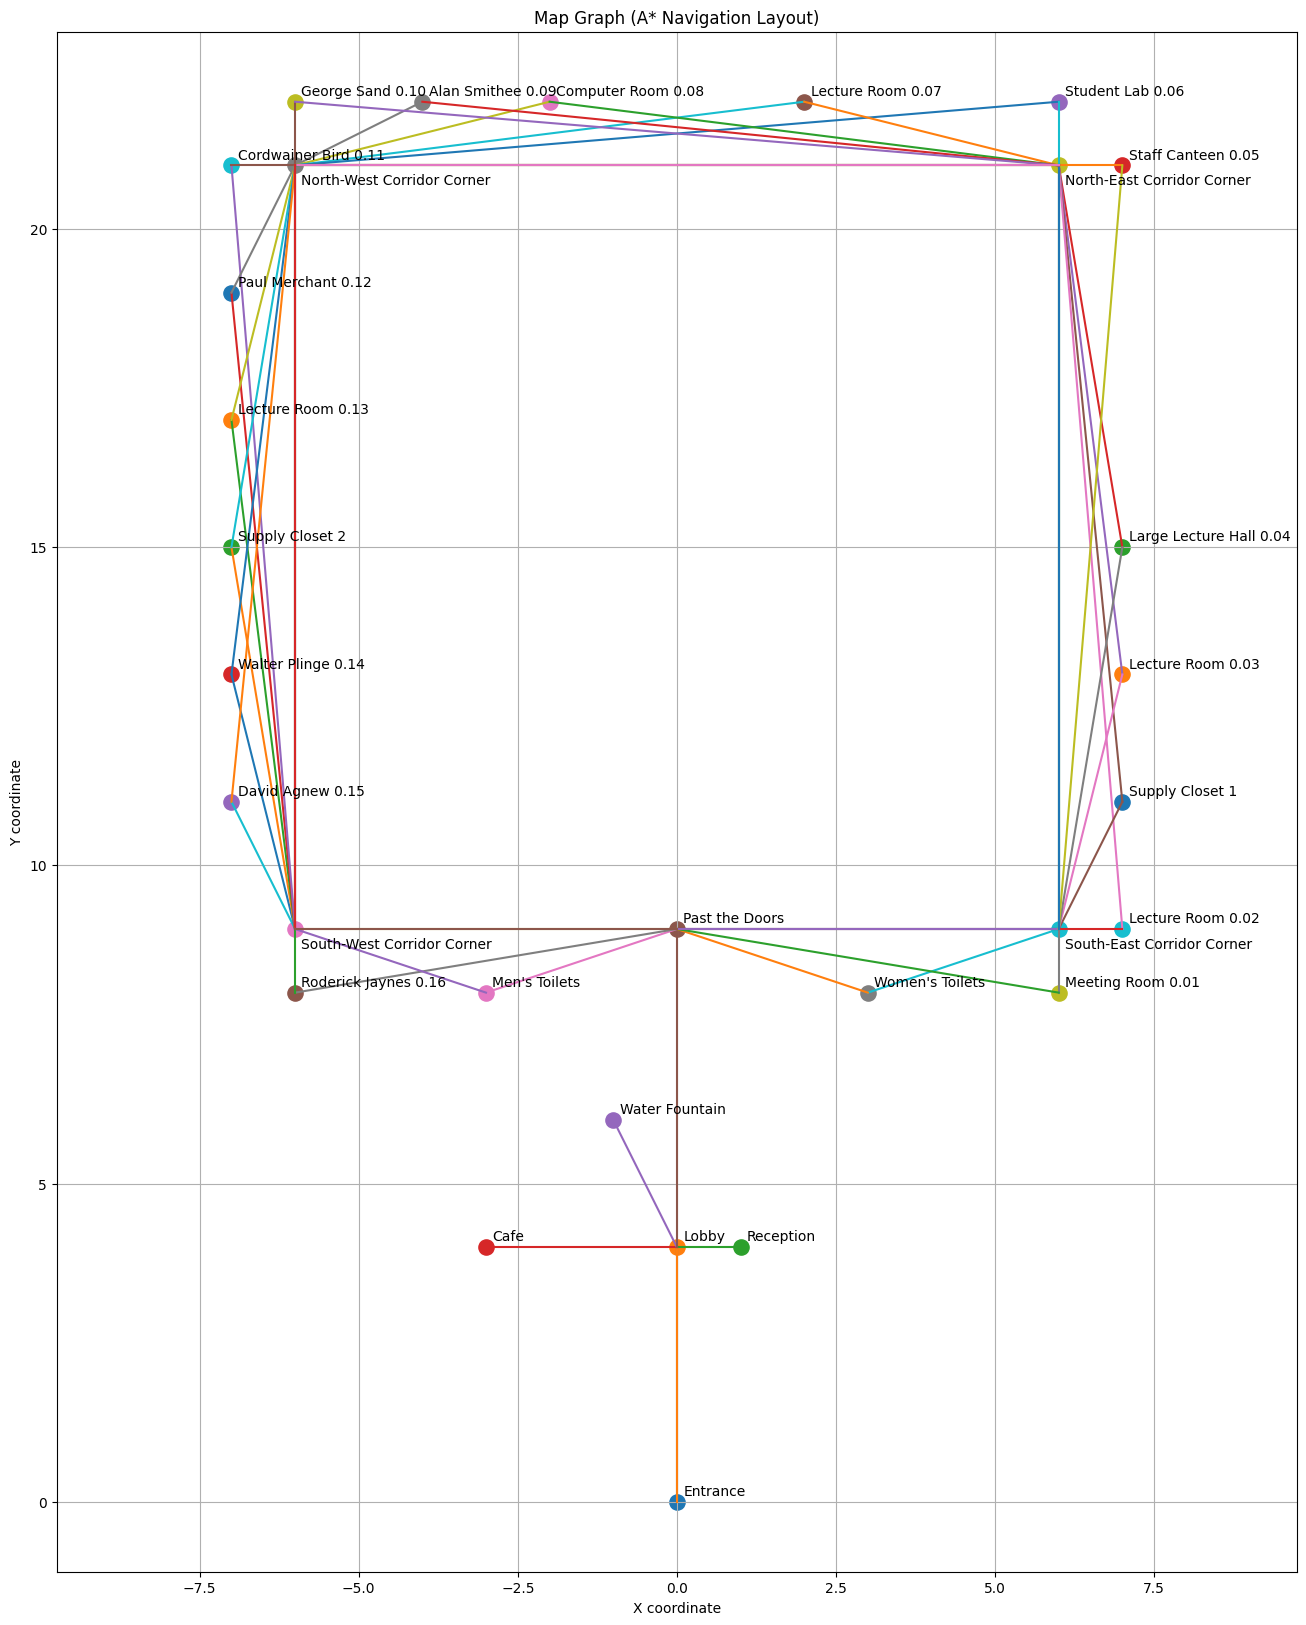

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 20))

# Draw the edges
for a, b, cost, instr in Edge_List:
    x_values = [Node_List[a].x, Node_List[b].x]
    y_values = [Node_List[a].y, Node_List[b].y]
    plt.plot(x_values, y_values)

# Draw nodes
for node_id, node in Node_List.items():
    plt.scatter(node.x, node.y, s=120)

# Add labels
for node_id, node in Node_List.items():
    if "corridor" in node_id:
        plt.text(node.x + 0.1, node.y - 0.3, node.name)
    else:
        plt.text(node.x + 0.1, node.y + 0.1, node.name)

plt.title("Map Graph (A* Navigation Layout)")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.grid(True)
plt.axis("equal")

plt.show()

# Test: LLM extraction of origin and destination from node list

In [1]:
import torch
import time
from transformers import TorchAoConfig, AutoModelForCausalLM, AutoTokenizer
from torchao.quantization import Int8DynamicActivationInt8WeightConfig, Int8WeightOnlyConfig

MODEL_NAME = "Qwen/Qwen3-0.6B"

#quant_config = Int8DynamicActivationInt8WeightConfig()
quant_config = Int8WeightOnlyConfig()
quantization_config = TorchAoConfig(quant_type=quant_config)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype="auto",
    device_map="auto",
    quantization_config=quantization_config
)

messages = [
    {"role": "system", "content": "Provide an answer from the following list of NODES:\n"},
    {"role": "system", "content": "entrance, lobby, reception, cafe, fountain, doors, toilets, meeting, 0.02, 0.03, 0.04, canteen, supply, lab, 0.07, computer, smithee, sand, bird, merchant, 0.13, plinge, agnew, jaynes\n"},
    {"role": "system", "content": "Provide your answer in the following format:"},
    {"role": "system", "content": "Origin: NODE, Destination: NODE"},
    {"role": "system", "content": "In the following sentence, which single NODE is the origin and which single NODE is the destination?\n"},
    #{"role": "user", "content": "What are the directions to the supply closet from Doctor Sand's office?"},
    #{"role": "user", "content": "How would I get from Lecture Room 0.03 to the lavatory?"},
    {"role": "user", "content": "From the cafe, where's the restroom?"},
    #{"role": "user", "content": "Where is the nearest toilet from the reception?"},
    #{"role": "user", "content": "What's the weather like today?"},
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=False # Switches between thinking and non-thinking modes. Default is True.
)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

start_time = time.time()
#generated_ids = model.generate(**model_inputs, max_length=500)
generated_ids = model.generate(**model_inputs, max_new_tokens=32768)
inference_time = time.time() - start_time
output_ids = generated_ids[0][len(model_inputs.input_ids[0]):].tolist()

# parse thinking content
try:
    index = len(output_ids) - output_ids[::-1].index(151668)
except ValueError:
    index = 0

thinking_content = tokenizer.decode(output_ids[:index], skip_special_tokens=True).strip("\n")
content = tokenizer.decode(output_ids[index:], skip_special_tokens=True).strip("\n")


#print("thinking content:", thinking_content)
print("content:", content)
print(f"inference time: {inference_time:.2f} seconds")

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

/home/rak/Documents/TCD/Semester 2/EEP55C34 Advanced AI/Project/lib/python3.12/site-packages/torchao/quantization/quant_api.py:925: UserWarning: Config Deprecation: version 1 of Int8WeightOnlyConfig is deprecated and will no longer be supported in a future release, please use version 2, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(
The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


content: Origin: cafe  
Destination: toilets
inference time: 13.36 seconds


# Test: LLM sentiment analysis

In [15]:
import torch
import time
from transformers import TorchAoConfig, AutoModelForCausalLM, AutoTokenizer
from torchao.quantization import Int8DynamicActivationInt8WeightConfig, Int8WeightOnlyConfig

MODEL_NAME = "Qwen/Qwen3-0.6B"

#quant_config = Int8DynamicActivationInt8WeightConfig()
quant_config = Int8WeightOnlyConfig()
quantization_config = TorchAoConfig(quant_type=quant_config)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype="auto",
    device_map="auto",
    quantization_config=quantization_config
)

messages = [
    {"role": "system", "content": "Provide your answer as a SINGLE WORD."},
    {"role": "system", "content": " Categorize the following sentence as ONE of the following: greeting, request, other\n"},
        
    #{"role": "user", "content": "Hello!"},
    #{"role": "user", "content": "What are the directions to the supply closet from Doctor Sand's office?"},
    #{"role": "user", "content": "How would I get from Lecture Room 0.03 to the lavatory?"},
    #{"role": "user", "content": "From the cafe, where's the restroom?"},
    #{"role": "user", "content": "Where is the nearest toilet from the reception?"},
    #{"role": "user", "content": "What's the weather like today?"},
    {"role": "user", "content": "Colorless green ideas sleep furiously."},
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=False # Switches between thinking and non-thinking modes. Default is True.
)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

start_time = time.time()
#generated_ids = model.generate(**model_inputs, max_length=500)
generated_ids = model.generate(**model_inputs, max_new_tokens=32768)
inference_time = time.time() - start_time
output_ids = generated_ids[0][len(model_inputs.input_ids[0]):].tolist()

# parse thinking content
try:
    index = len(output_ids) - output_ids[::-1].index(151668)
except ValueError:
    index = 0

thinking_content = tokenizer.decode(output_ids[:index], skip_special_tokens=True).strip("\n")
content = tokenizer.decode(output_ids[index:], skip_special_tokens=True).strip("\n")

#print("thinking content:", thinking_content)
print("content:", content)
print(f"inference time: {inference_time:.2f} seconds")


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


content: greeting
inference time: 4.18 seconds
